# 05 — Model Training (CLV Regression)

## Objective
Train regression models to predict clv_next_12months (₹)
for each customer using the 49 features built in
Feature Engineering.

## Key Difference From Previous Projects
Target variable is continuous and heavily right-skewed:
  Mean ₹44,629 vs Median ₹8,993 — 4.97x difference
  Max ₹900,000 vs Min ₹0

Strategy: Train models on log(1 + CLV) as target,
evaluate on original ₹ scale after back-transformation.
This is called log-space regression.

## Models
1. Ridge Regression      — linear baseline
2. Random Forest         — non-linear ensemble
3. XGBoost               — gradient boosting
4. LightGBM              — fast gradient boosting

## Primary Metrics
RMSE        — penalizes large errors heavily (in ₹)
MAE         — average absolute error (in ₹)
R²          — proportion of variance explained
MAPE        — mean absolute percentage error

## Secondary Metric
Segment-level RMSE — how well do we predict HNI vs students?
Getting HNI right matters more than getting students right
(HNI = 63.8% of portfolio CLV).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection  import train_test_split, KFold, cross_val_score
from sklearn.preprocessing    import StandardScaler
from sklearn.linear_model     import Ridge
from sklearn.ensemble         import RandomForestRegressor
from sklearn.metrics          import (
    mean_squared_error, mean_absolute_error, r2_score
)
from xgboost  import XGBRegressor
from lightgbm import LGBMRegressor

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams["figure.dpi"]      = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PROCESSED = "../data/processed"

# Load modeling data
modeling_df  = pd.read_csv(f"{PROCESSED}/modeling_data.csv")

with open(f"{PROCESSED}/feature_cols.pkl","rb") as f:
    feature_cols = pickle.load(f)

print("Data loaded ✅")
print(f"  Rows     : {len(modeling_df):,}")
print(f"  Columns  : {len(modeling_df.columns)}")
print(f"  Features : {len(feature_cols)}")

print(f"\nTarget variable — clv_next_12months:")
print(f"  Mean   : ₹{modeling_df['clv_next_12months'].mean():>12,.2f}")
print(f"  Median : ₹{modeling_df['clv_next_12months'].median():>12,.2f}")
print(f"  Std    : ₹{modeling_df['clv_next_12months'].std():>12,.2f}")
print(f"  Skew   : {modeling_df['clv_next_12months'].skew():>8.4f}")

print(f"\nLog CLV — log_clv:")
print(f"  Mean   : {modeling_df['log_clv'].mean():>8.4f}")
print(f"  Std    : {modeling_df['log_clv'].std():>8.4f}")
print(f"  Skew   : {modeling_df['log_clv'].skew():>8.4f}")
print(f"  (much closer to normal — better for linear models)")

Data loaded ✅
  Rows     : 50,000
  Columns  : 62
  Features : 49

Target variable — clv_next_12months:
  Mean   : ₹   44,628.94
  Median : ₹    8,992.96
  Std    : ₹  115,561.83
  Skew   :   5.0460

Log CLV — log_clv:
  Mean   :   8.3245
  Std    :   3.1612
  Skew   :  -1.1409
  (much closer to normal — better for linear models)


In [2]:
print("PREPARING FEATURES AND SPLIT\n")

# Clean feature list — only columns that exist and are numeric
feature_cols = [
    c for c in feature_cols
    if c in modeling_df.columns
    and modeling_df[c].dtype != object
]

# Fill any remaining nulls with column median
for col in feature_cols:
    if modeling_df[col].isnull().sum() > 0:
        median = modeling_df[col].median()
        modeling_df[col] = modeling_df[col].fillna(median)
        print(f"  Filled {col} nulls with median {median:.2f}")

X = modeling_df[feature_cols].copy()
y_raw = modeling_df["clv_next_12months"].copy()  # original ₹
y_log = modeling_df["log_clv"].copy()            # log transformed

# Stratified split by CLV bucket to ensure
# HNI customers appear in both train and test
from sklearn.model_selection import train_test_split

X_train, X_test, \
y_train_raw, y_test_raw, \
y_train_log, y_test_log = train_test_split(
    X, y_raw, y_log,
    test_size=0.2,
    random_state=42,
    stratify=modeling_df["clv_bucket"]
)

# Scale features for Ridge Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]:,} rows")
print(f"Test  : {X_test.shape[0]:,} rows")
print(f"Features: {X_train.shape[1]}")

print(f"\nTrain CLV bucket distribution:")
train_buckets = modeling_df.loc[X_train.index,"clv_bucket"].value_counts()
test_buckets  = modeling_df.loc[X_test.index,"clv_bucket"].value_counts()
for bucket in ["very_high","high","medium","low","very_low"]:
    if bucket in train_buckets:
        print(f"  {bucket:<12}: train={train_buckets.get(bucket,0):>5,} "
              f"test={test_buckets.get(bucket,0):>4,}")

PREPARING FEATURES AND SPLIT

Train : 40,000 rows
Test  : 10,000 rows
Features: 49

Train CLV bucket distribution:
  very_high   : train=3,408 test= 852
  high        : train=11,351 test=2,838
  medium      : train=8,073 test=2,018
  low         : train=7,158 test=1,790
  very_low    : train=10,010 test=2,502


In [3]:
def evaluate_model(name, y_true_raw, y_pred_raw, segment_col=None):
    """
    Comprehensive regression evaluation for CLV prediction.

    We evaluate in ORIGINAL ₹ scale after back-transformation.
    All reported metrics are in ₹ — interpretable by business.

    y_true_raw : actual CLV in ₹
    y_pred_raw : predicted CLV in ₹ (already back-transformed)
    """
    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    mae  = mean_absolute_error(y_true_raw, y_pred_raw)
    r2   = r2_score(y_true_raw, y_pred_raw)

    # MAPE — exclude near-zero actual values to avoid division explosion
    mask = y_true_raw > 100
    mape = (
        np.mean(np.abs(
            (y_true_raw[mask] - y_pred_raw[mask]) / y_true_raw[mask]
        )) * 100
        if mask.sum() > 0 else np.nan
    )

    return {
        "model"     : name,
        "rmse"      : rmse,
        "mae"       : mae,
        "r2"        : r2,
        "mape"      : mape,
        "y_pred"    : y_pred_raw,
    }

def back_transform(y_log_pred):
    """Convert log predictions back to ₹."""
    return np.expm1(y_log_pred)

print("Evaluation function defined ✅")
print(f"\nMetrics explanation:")
print(f"  RMSE : Root Mean Squared Error — penalizes large errors")
print(f"         heavily. A ₹50K RMSE means predictions are on")
print(f"         average ₹50K off on squared-error basis.")
print(f"  MAE  : Mean Absolute Error — average ₹ error per customer")
print(f"  R²   : 1.0 = perfect, 0.0 = mean baseline, <0 = worse than mean")
print(f"  MAPE : % error on customers with CLV > ₹100 only")
print(f"         (low-CLV customers have huge % errors by nature)")

Evaluation function defined ✅

Metrics explanation:
  RMSE : Root Mean Squared Error — penalizes large errors
         heavily. A ₹50K RMSE means predictions are on
         average ₹50K off on squared-error basis.
  MAE  : Mean Absolute Error — average ₹ error per customer
  R²   : 1.0 = perfect, 0.0 = mean baseline, <0 = worse than mean
  MAPE : % error on customers with CLV > ₹100 only
         (low-CLV customers have huge % errors by nature)


In [4]:
results_list   = []
trained_models = {}

print("=" * 60)
print(" TRAINING ALL MODELS ON LOG(CLV) TARGET")
print("=" * 60)
print(f" Train size : {len(X_train):,}")
print(f" Test size  : {len(X_test):,}")
print(f" Features   : {len(feature_cols)}")
print("=" * 60)

# ── 1. Ridge Regression ───────────────────────────────────────
print("\n1. Ridge Regression (linear baseline)...")
ridge = Ridge(alpha=10.0, random_state=42)
ridge.fit(X_train_scaled, y_train_log)
y_pred_log_ridge = ridge.predict(X_test_scaled)
y_pred_ridge     = back_transform(y_pred_log_ridge)
y_pred_ridge     = np.clip(y_pred_ridge, 0, None)

result_ridge = evaluate_model(
    "Ridge Regression", y_test_raw, y_pred_ridge
)
results_list.append(result_ridge)
trained_models["Ridge Regression"] = ridge
print(f"   RMSE: ₹{result_ridge['rmse']:>12,.2f}  "
      f"MAE: ₹{result_ridge['mae']:>10,.2f}  "
      f"R²: {result_ridge['r2']:.4f}")

# ── 2. Random Forest ──────────────────────────────────────────
print("\n2. Random Forest...")
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train_log)
y_pred_log_rf = rf.predict(X_test)
y_pred_rf     = back_transform(y_pred_log_rf)
y_pred_rf     = np.clip(y_pred_rf, 0, None)

result_rf = evaluate_model(
    "Random Forest", y_test_raw, y_pred_rf
)
results_list.append(result_rf)
trained_models["Random Forest"] = rf
print(f"   RMSE: ₹{result_rf['rmse']:>12,.2f}  "
      f"MAE: ₹{result_rf['mae']:>10,.2f}  "
      f"R²: {result_rf['r2']:.4f}")

# ── 3. XGBoost ────────────────────────────────────────────────
print("\n3. XGBoost...")
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    verbosity=0
)
xgb.fit(
    X_train, y_train_log,
    eval_set=[(X_test, y_test_log)],
    verbose=False
)
y_pred_log_xgb = xgb.predict(X_test)
y_pred_xgb     = back_transform(y_pred_log_xgb)
y_pred_xgb     = np.clip(y_pred_xgb, 0, None)

result_xgb = evaluate_model(
    "XGBoost", y_test_raw, y_pred_xgb
)
results_list.append(result_xgb)
trained_models["XGBoost"] = xgb
print(f"   RMSE: ₹{result_xgb['rmse']:>12,.2f}  "
      f"MAE: ₹{result_xgb['mae']:>10,.2f}  "
      f"R²: {result_xgb['r2']:.4f}")

# ── 4. LightGBM ───────────────────────────────────────────────
print("\n4. LightGBM...")
lgbm = LGBMRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    random_state=42,
    verbose=-1
)
lgbm.fit(
    X_train, y_train_log,
    eval_set=[(X_test, y_test_log)]
)
y_pred_log_lgbm = lgbm.predict(X_test)
y_pred_lgbm     = back_transform(y_pred_log_lgbm)
y_pred_lgbm     = np.clip(y_pred_lgbm, 0, None)

result_lgbm = evaluate_model(
    "LightGBM", y_test_raw, y_pred_lgbm
)
results_list.append(result_lgbm)
trained_models["LightGBM"] = lgbm
print(f"   RMSE: ₹{result_lgbm['rmse']:>12,.2f}  "
      f"MAE: ₹{result_lgbm['mae']:>10,.2f}  "
      f"R²: {result_lgbm['r2']:.4f}")

print("\n✅ All models trained")

 TRAINING ALL MODELS ON LOG(CLV) TARGET
 Train size : 40,000
 Test size  : 10,000
 Features   : 49

1. Ridge Regression (linear baseline)...
   RMSE: ₹   97,677.73  MAE: ₹ 27,627.40  R²: 0.3027

2. Random Forest...
   RMSE: ₹   57,518.68  MAE: ₹ 17,918.08  R²: 0.7582

3. XGBoost...
   RMSE: ₹   61,742.61  MAE: ₹ 17,948.57  R²: 0.7214

4. LightGBM...
   RMSE: ₹   61,596.24  MAE: ₹ 17,983.30  R²: 0.7227

✅ All models trained


In [5]:
print("MODEL COMPARISON RESULTS\n")

results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "y_pred"}
    for r in results_list
]).sort_values("rmse").reset_index(drop=True)
results_df.index += 1

print(f"{'Rank':<6} {'Model':<22} {'RMSE (₹)':>14} "
      f"{'MAE (₹)':>12} {'R²':>8} {'MAPE %':>8}")
print("-" * 72)
for i, row in results_df.iterrows():
    print(f"  {i:<4} {row['model']:<22} "
          f"₹{row['rmse']:>12,.2f} "
          f"₹{row['mae']:>10,.2f} "
          f"{row['r2']:>8.4f} "
          f"{row['mape']:>7.2f}%")

# Baseline comparison
baseline_rmse = np.sqrt(mean_squared_error(
    y_test_raw,
    np.full_like(y_test_raw, y_train_raw.mean())
))
baseline_mae = mean_absolute_error(
    y_test_raw,
    np.full_like(y_test_raw, y_train_raw.mean())
)
print(f"\n  {'Baseline (mean)':<26} "
      f"₹{baseline_rmse:>12,.2f} "
      f"₹{baseline_mae:>10,.2f} "
      f"{'0.0000':>8} {'N/A':>8}")

print(f"\nBest model improvement over mean baseline:")
best_rmse = results_df["rmse"].min()
print(f"  RMSE reduction: {(1 - best_rmse/baseline_rmse)*100:.1f}%")
print(f"  Best model    : {results_df.iloc[0]['model']}")

MODEL COMPARISON RESULTS

Rank   Model                        RMSE (₹)      MAE (₹)       R²   MAPE %
------------------------------------------------------------------------
  1    Random Forest          ₹   57,518.68 ₹ 17,918.08   0.7582  412.92%
  2    LightGBM               ₹   61,596.24 ₹ 17,983.30   0.7227  420.11%
  3    XGBoost                ₹   61,742.61 ₹ 17,948.57   0.7214  408.86%
  4    Ridge Regression       ₹   97,677.73 ₹ 27,627.40   0.3027  438.62%

  Baseline (mean)            ₹  116,977.59 ₹ 55,278.26   0.0000      N/A

Best model improvement over mean baseline:
  RMSE reduction: 50.8%
  Best model    : Random Forest


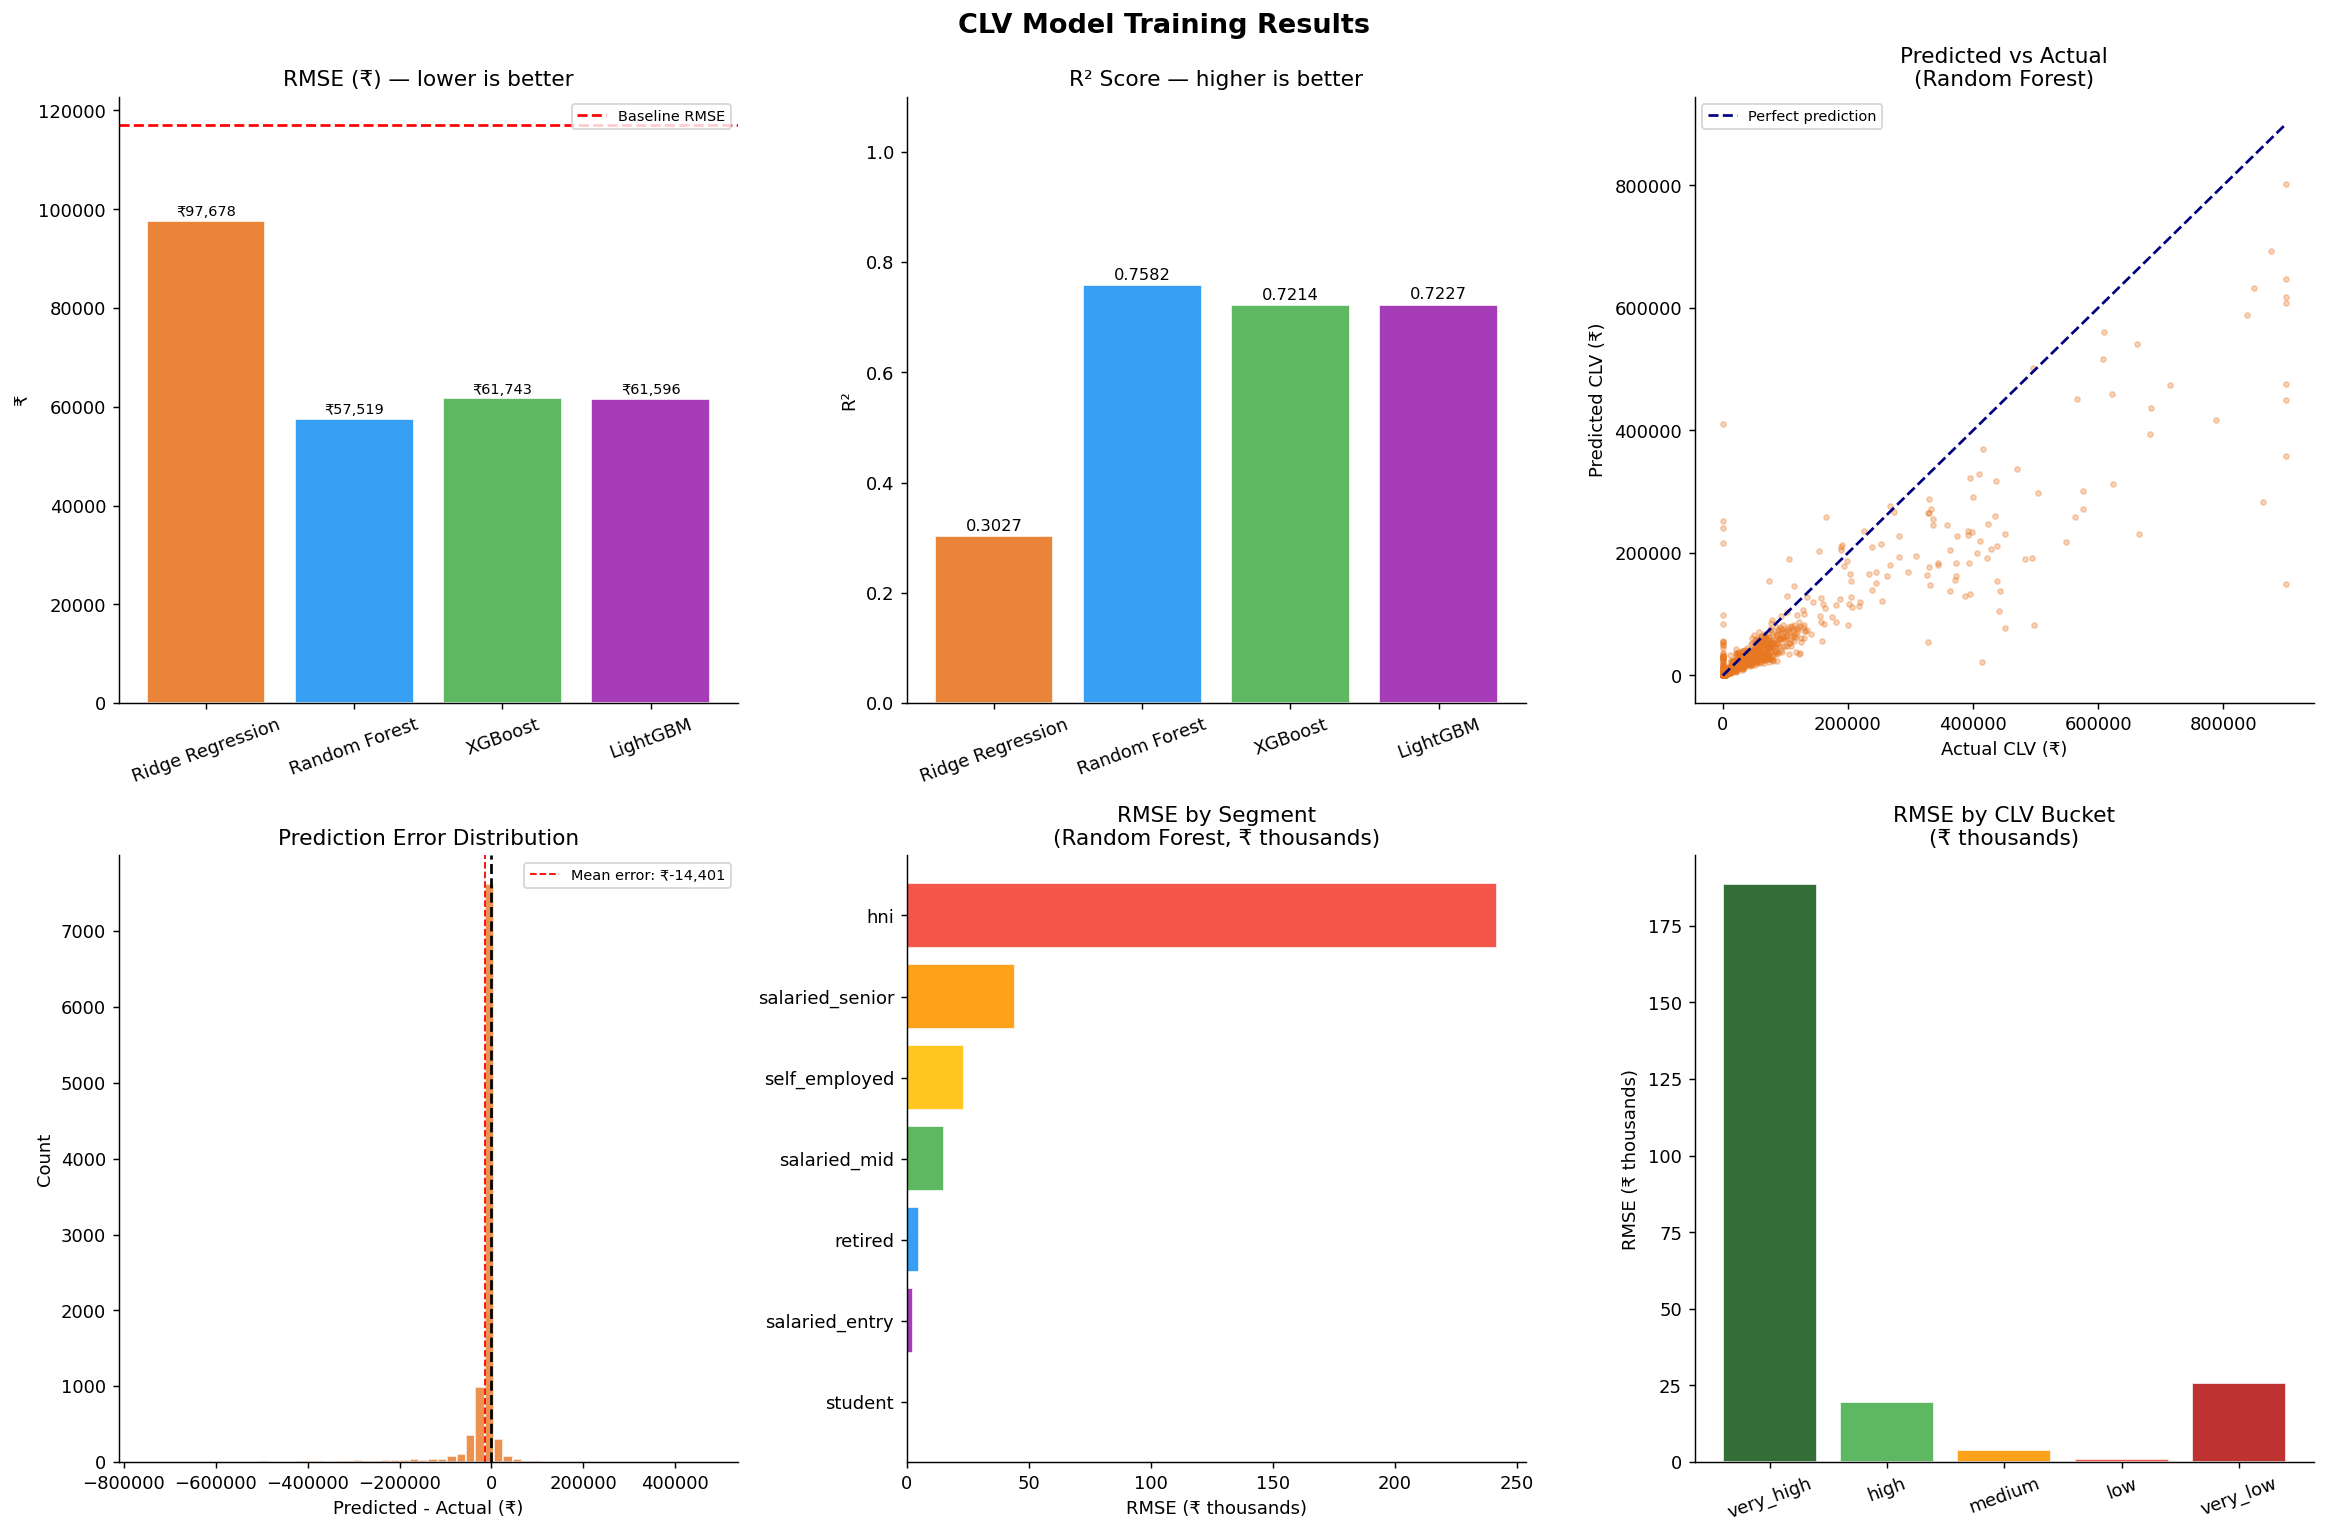

In [6]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("CLV Model Training Results", fontsize=15, fontweight="bold")
gs  = gridspec.GridSpec(2, 3, figure=fig)

model_colors = ["#E87722","#2196F3","#4CAF50","#9C27B0"]
model_names  = [r["model"] for r in results_list]
rmse_vals    = [r["rmse"]  for r in results_list]
mae_vals     = [r["mae"]   for r in results_list]
r2_vals      = [r["r2"]    for r in results_list]

# ── RMSE comparison ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(model_names, rmse_vals,
        color=model_colors, edgecolor="white", alpha=0.9)
ax1.axhline(baseline_rmse, color="red", linestyle="--",
            linewidth=1.5, label=f"Baseline RMSE")
ax1.set_title("RMSE (₹) — lower is better")
ax1.set_ylabel("₹")
ax1.tick_params(axis="x", rotation=20)
ax1.legend(fontsize=8)
for i, v in enumerate(rmse_vals):
    ax1.text(i, v + 1000, f"₹{v:,.0f}", ha="center", fontsize=8)

# ── R² comparison ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(model_names, r2_vals,
        color=model_colors, edgecolor="white", alpha=0.9)
ax2.set_title("R² Score — higher is better")
ax2.set_ylabel("R²")
ax2.tick_params(axis="x", rotation=20)
ax2.set_ylim(0, 1.1)
for i, v in enumerate(r2_vals):
    ax2.text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=9)

# ── Predicted vs Actual (best model) ─────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
best_idx    = np.argmin(rmse_vals)
best_name   = model_names[best_idx]
best_preds  = results_list[best_idx]["y_pred"]

# Sample 2000 for scatter plot clarity
sample_idx = np.random.choice(len(y_test_raw), 2000, replace=False)
ax3.scatter(
    y_test_raw.values[sample_idx],
    best_preds[sample_idx],
    alpha=0.3, s=8, color="#E87722"
)
max_val = max(y_test_raw.max(), best_preds.max())
ax3.plot([0, max_val],[0, max_val],
         "navy", linestyle="--", linewidth=1.5,
         label="Perfect prediction")
ax3.set_title(f"Predicted vs Actual\n({best_name})")
ax3.set_xlabel("Actual CLV (₹)")
ax3.set_ylabel("Predicted CLV (₹)")
ax3.legend(fontsize=8)

# ── Error distribution ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
errors = best_preds - y_test_raw.values
ax4.hist(errors, bins=60, color="#E87722",
         edgecolor="white", alpha=0.8)
ax4.axvline(0, color="black", linestyle="--", linewidth=1.5)
ax4.axvline(errors.mean(), color="red", linestyle="--",
            linewidth=1, label=f"Mean error: ₹{errors.mean():,.0f}")
ax4.set_title("Prediction Error Distribution")
ax4.set_xlabel("Predicted - Actual (₹)")
ax4.set_ylabel("Count")
ax4.legend(fontsize=8)

# ── Segment-level RMSE ────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
segment_col = modeling_df.loc[X_test.index, "segment"]
seg_rmse    = {}
for seg in segment_col.unique():
    mask = segment_col.values == seg
    if mask.sum() > 10:
        seg_rmse[seg] = np.sqrt(mean_squared_error(
            y_test_raw.values[mask],
            best_preds[mask]
        ))

seg_rmse_sorted = dict(
    sorted(seg_rmse.items(), key=lambda x: x[1], reverse=True)
)
colors_seg = ["#F44336","#FF9800","#FFC107",
              "#4CAF50","#2196F3","#9C27B0","#607D8B"]
ax5.barh(
    list(seg_rmse_sorted.keys()),
    [v/1000 for v in seg_rmse_sorted.values()],
    color=colors_seg[:len(seg_rmse_sorted)],
    edgecolor="white", alpha=0.9
)
ax5.set_title(f"RMSE by Segment\n({best_name}, ₹ thousands)")
ax5.set_xlabel("RMSE (₹ thousands)")
ax5.invert_yaxis()

# ── CLV bucket RMSE ───────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
bucket_col  = modeling_df.loc[X_test.index, "clv_bucket"]
bucket_rmse = {}
bucket_order= ["very_high","high","medium","low","very_low"]
for bkt in bucket_order:
    mask = bucket_col.values == bkt
    if mask.sum() > 0:
        bucket_rmse[bkt] = np.sqrt(mean_squared_error(
            y_test_raw.values[mask],
            best_preds[mask]
        ))

colors_bkt = ["#1B5E20","#4CAF50","#FF9800","#F44336","#B71C1C"]
ax6.bar(
    list(bucket_rmse.keys()),
    [v/1000 for v in bucket_rmse.values()],
    color=colors_bkt[:len(bucket_rmse)],
    edgecolor="white", alpha=0.9
)
ax6.set_title("RMSE by CLV Bucket\n(₹ thousands)")
ax6.set_ylabel("RMSE (₹ thousands)")
ax6.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(f"{PROCESSED}/model_01_training_results.png",
            dpi=130, bbox_inches="tight")
plt.show()

In [7]:
print("CROSS VALIDATION — Top 2 Models\n")

top2 = results_df["model"].head(2).tolist()
kf   = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name in top2:
    model = trained_models[name]
    X_cv  = X_train_scaled if name == "Ridge Regression" else X_train

    scores = cross_val_score(
        model, X_cv, y_train_log,
        cv=kf, scoring="r2", n_jobs=-1
    )

    cv_results.append({
        "model"      : name,
        "cv_r2_mean" : scores.mean(),
        "cv_r2_std"  : scores.std(),
        "test_r2"    : results_df[
            results_df["model"]==name
        ]["r2"].values[0],
    })

    print(f"  {name:<22}: "
          f"CV R² = {scores.mean():.4f} ± {scores.std():.4f}  |  "
          f"Test R² = {results_df[results_df['model']==name]['r2'].values[0]:.4f}")

cv_df = pd.DataFrame(cv_results)

# Check for overfitting
print("\nOverfitting check (CV R² vs Test R²):")
for _, row in cv_df.iterrows():
    gap = row["test_r2"] - row["cv_r2_mean"]
    flag = "✅ OK" if abs(gap) < 0.05 else "⚠️ Check"
    print(f"  {row['model']:<22}: gap = {gap:+.4f}  {flag}")

# Save best model
best_model_name = results_df.iloc[0]["model"]
best_model_obj  = trained_models[best_model_name]

model_filename = best_model_name.lower().replace(" ","_")
with open(f"{PROCESSED}/{model_filename}_clv.pkl","wb") as f:
    pickle.dump(best_model_obj, f)
with open(f"{PROCESSED}/scaler_clv.pkl","wb") as f:
    pickle.dump(scaler, f)

results_df.drop(columns=["y_pred"],errors="ignore") \
          .to_csv(f"{PROCESSED}/model_results.csv", index=False)

print(f"\n✅ Best model saved: {model_filename}_clv.pkl")
print(f"✅ Scaler saved    : scaler_clv.pkl")
print(f"✅ Results saved   : model_results.csv")
print(f"\nBest model : {best_model_name}")
print(f"Test RMSE  : ₹{results_df.iloc[0]['rmse']:>12,.2f}")
print(f"Test R²    : {results_df.iloc[0]['r2']:>8.4f}")
print(f"Test MAE   : ₹{results_df.iloc[0]['mae']:>12,.2f}")

CROSS VALIDATION — Top 2 Models

  Random Forest         : CV R² = 0.7470 ± 0.0082  |  Test R² = 0.7582
  LightGBM              : CV R² = 0.7453 ± 0.0075  |  Test R² = 0.7227

Overfitting check (CV R² vs Test R²):
  Random Forest         : gap = +0.0112  ✅ OK
  LightGBM              : gap = -0.0225  ✅ OK

✅ Best model saved: random_forest_clv.pkl
✅ Scaler saved    : scaler_clv.pkl
✅ Results saved   : model_results.csv

Best model : Random Forest
Test RMSE  : ₹   57,518.68
Test R²    :   0.7582
Test MAE   : ₹   17,918.08
